# Versioned SER Result Summary

Notebook gọn để tổng hợp tất cả `cross_session_summary.json` thành bảng mean ± std và heatmap theo held-out session. Notebook này không training, chỉ đọc kết quả đã có.


## 1. Setup


In [1]:
from __future__ import annotations

import json
import os
import re
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp") / "matplotlib"))

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    display
except NameError:
    def display(value):
        print(value)

sns.set_theme(style="whitegrid", context="paper")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name in {"notebook", "notebooks"}:
    PROJECT_ROOT = PROJECT_ROOT.parent
RESULTS_DIR = PROJECT_ROOT / "results"
# Set to None or [] to read every results folder.
# Example: FOLDERS = ["versioned_loso", "tim_ablations", "ablation_model_loso"]
FOLDERS = ["versioned_loso", "tim_ablations", "cim_full_loso", "cim_ablation_loso", "fusion_model_loso", "mal_ablation_loso"]
OUT_DIR = PROJECT_ROOT / "reports" / "versioned_result_summary"
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

METRICS = ["WA", "UA", "WF1", "Macro-F1"]
PRIMARY_METRIC = "Macro-F1"
print("PROJECT_ROOT =", PROJECT_ROOT)
print("OUT_DIR      =", OUT_DIR)
print("FOLDERS      =", FOLDERS if FOLDERS else "ALL")



PROJECT_ROOT = /Users/ngocbao/Documents/Document/research/main/speech/exps/demo
OUT_DIR      = /Users/ngocbao/Documents/Document/research/main/speech/exps/demo/reports/versioned_result_summary
FOLDERS      = ['versioned_loso', 'tim_ablations', 'cim_full_loso', 'cim_ablation_loso', 'fusion_model_loso', 'mal_ablation_loso']


## 2. Load Cross-Session Summaries


In [2]:
def read_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def pct(value: float) -> float:
    return 100.0 * float(value)


def mean_std_text(mean: float, std: float) -> str:
    return f"{pct(mean):.2f} ± {pct(std):.2f}"


def infer_family(path: Path) -> str:
    parts = path.parts
    for key in [
        "versioned_loso",
        "ablation_model_loso",
        "ablation_loso",
        "tim_ablations",
        "cim_loso",
        "cim_full_loso",
        "cim_ablation_loso",
        "fusion_model_loso",
        "mal_ablation_loso",
    ]:
        if key in parts:
            return key
    if "cross_session" in parts:
        return "legacy_loso"
    return "other"


def infer_model_name(path: Path, payload: dict) -> str:
    text = str(path)
    trainer = str(payload.get("trainer_module", ""))
    if "tim_zero" in text:
        return "TIM-zero"
    if "tim_shuffled" in text:
        return "TIM-shuffled"
    if "tim_no_" in text or "tim_overlap_only" in text:
        return path.parents[2].name if "tim_ablations" in path.parts else path.parents[3].name
    if "cim_ablation_loso" in text:
        if "no_relative_gap" in text:
            return "CIM ablation: no relative gap"
        if "no_overlap_ratio" in text:
            return "CIM ablation: no overlap ratio"
        if "no_speaker_switch" in text:
            return "CIM ablation: no speaker switch"
        if "no_speaker_overlap_style" in text:
            return "CIM ablation: no speaker overlap style"
        return path.parents[2].name
    if "mal_ablation_loso" in text:
        if "zero_state" in text:
            return "CDM ablation: zero state"
        if "no_update" in text:
            return "CDM ablation: no update"
        if "shuffled_memory" in text:
            return "CDM ablation: shuffled memory"
        return path.parents[2].name
    if "fusion_model_loso" in text:
        if "residual_gated" in text:
            return "CIM fusion: residual gated"
        if "residual_sum" in text:
            return "CIM fusion: residual sum"
        if "branch_sum" in text:
            return "CIM fusion: branch sum"
        if "dialogue_only" in text:
            return "CIM fusion: dialogue only"
        if "temporal_only" in text:
            return "CIM fusion: interaction only"
        return path.parents[2].name
    if "cim_dual_interaction4" in text or "dual_interaction4" in text or "cim_full_loso" in text or "cim_loso" in text or "cim_branch_concat_interaction4" in text or "branch_concat_interaction4" in text:
        return "CIM dual interaction-4"
    if "cim_concat_interaction4" in text or "/concat_interaction4/" in text:
        return "CIM concat interaction-4"
    if "v3_2_tim_compact_primitives" in text:
        return "TIM v3.2 compact primitives"
    if "v3_1_tim_recommended_v2" in text or "wavlm_tim_v2_recommended" in text:
        return "TIM v3.1 recommended-v2"
    if "v2_2_2_dual_temporal_dialogue_fuse" in text or "wavlm_dual_branch_temporal_first" in text:
        return "Dual v2.2.2 temporal-first"
    if "v2_2_1_dual_dialogue_temporal_fuse" in text or "dual_branch_3phase" in text or "wavlm_dual_branch/cross_session" in text:
        return "Dual v2.2.1 3-phase"
    if "v2_1_dual_end2end" in text or "wavlm_dual_branch_end2end" in text:
        return "Dual v2.1 end-to-end"
    if "v1_tim_concat" in text or "wavlm_tim_end2end" in text or "wavlm_tim_loso" in text or trainer.endswith("train_wavlm_tim"):
        return "TIM v1 concat"
    if "wavlm_mal" in text or trainer.endswith("train_wavlm_mal"):
        return "MAL"
    if "wavlm_baseline" in text or trainer.endswith("train_wavlm_baseline"):
        return "Baseline"
    return path.parents[2].name if len(path.parents) > 2 else path.stem


def infer_version(path: Path, model_name: str) -> str:
    if model_name.startswith("CIM ablation"):
        return "CIM ablation"
    if model_name.startswith("CIM fusion"):
        return "CIM fusion"
    if model_name.startswith("CIM"):
        return "CIM"
    if model_name.startswith("CDM ablation"):
        return "CDM ablation"
    if "v3.1" in model_name:
        return "3.1"
    if "v2.2.2" in model_name:
        return "2.2.2"
    if "v2.2.1" in model_name:
        return "2.2.1"
    if "v2.1" in model_name:
        return "2.1"
    if "v1" in model_name:
        return "1"
    return "control"


def infer_setting(path: Path, payload: dict) -> str:
    cfg = payload.get("config", {}) if isinstance(payload.get("config"), dict) else {}
    text = str(path)
    if "setting_B" in text:
        return "B"
    if "setting_A" in text:
        return "A"
    # Existing results are frozen/precomputed fair runs unless config says otherwise.
    return "A"


def seed_from_path(path: Path) -> int | None:
    m = re.search(r"seed_(\d+)", str(path))
    return int(m.group(1)) if m else None


def result_top_folder(path: Path) -> str:
    try:
        rel = path.relative_to(RESULTS_DIR)
    except ValueError:
        return ""
    return rel.parts[0] if rel.parts else ""


def folder_allowed(path: Path) -> bool:
    if not FOLDERS:
        return True
    allowed = {str(folder).strip("/") for folder in FOLDERS}
    return result_top_folder(path) in allowed

all_summary_paths = sorted(RESULTS_DIR.glob("**/cross_session_summary.json"))
summary_paths = [path for path in all_summary_paths if folder_allowed(path)]
aggregate_rows = []
fold_rows = []

for path in summary_paths:
    payload = read_json(path)
    family = infer_family(path)
    model_name = infer_model_name(path, payload)
    version = infer_version(path, model_name)
    setting = infer_setting(path, payload)
    seed = seed_from_path(path)
    run_name = path.parent.name
    for metric in METRICS:
        item = payload.get("aggregate", {}).get(metric)
        if not item:
            continue
        aggregate_rows.append({
            "family": family,
            "setting": setting,
            "version": version,
            "model": model_name,
            "seed": seed,
            "run_name": run_name,
            "metric": metric,
            "mean": float(item["mean"]),
            "std": float(item["std"]),
            "n": int(item.get("n", 5)),
            "summary_path": str(path),
        })
    for fold in payload.get("folds", []):
        for metric in METRICS:
            if metric not in fold.get("metrics", {}):
                continue
            fold_rows.append({
                "family": family,
                "setting": setting,
                "version": version,
                "model": model_name,
                "seed": seed,
                "run_name": run_name,
                "test_session": int(fold["test_session"]),
                "metric": metric,
                "value": float(fold["metrics"][metric]),
                "summary_path": str(path),
            })

aggregate = pd.DataFrame(aggregate_rows)
folds = pd.DataFrame(fold_rows)
aggregate.to_csv(OUT_DIR / "all_cross_session_aggregate_long.csv", index=False)
folds.to_csv(OUT_DIR / "all_cross_session_folds_long.csv", index=False)
print("summaries found:", len(summary_paths), "/", len(all_summary_paths))
print("folders included:", sorted({result_top_folder(path) for path in summary_paths}))
print("aggregate rows:", len(aggregate))
display(aggregate.head())



summaries found: 29 / 32
folders included: ['cim_ablation_loso', 'cim_full_loso', 'fusion_model_loso', 'mal_ablation_loso', 'tim_ablations', 'versioned_loso']
aggregate rows: 116


,family,setting,version,model,seed,run_name,metric,mean,std,n,summary_path
0,cim_ablation_loso,A,CIM ablation,CIM ablation: no overlap ratio,NaN,run_20260701_155704,WA,0.647373,0.051105,5,/Users/ngocbao/Documents/Document/research/mai...
1,cim_ablation_loso,A,CIM ablation,CIM ablation: no overlap ratio,NaN,run_20260701_155704,UA,0.629685,0.047127,5,/Users/ngocbao/Documents/Document/research/mai...
2,cim_ablation_loso,A,CIM ablation,CIM ablation: no overlap ratio,NaN,run_20260701_155704,WF1,0.642681,0.053283,5,/Users/ngocbao/Documents/Document/research/mai...
3,cim_ablation_loso,A,CIM ablation,CIM ablation: no overlap ratio,NaN,run_20260701_155704,Macro-F1,0.618860,0.046740,5,/Users/ngocbao/Documents/Document/research/mai...
4,cim_ablation_loso,A,CIM ablation,CIM ablation: no relative gap,NaN,run_20260701_105320,WA,0.643613,0.062855,5,/Users/ngocbao/Documents/Document/research/mai...


## Prediction File Index

Log đường dẫn tới `predictions.csv` của từng version/run/fold để dễ đối chiếu demo, paired error và qualitative analysis.


In [3]:
def row_count_csv(path: Path) -> int | None:
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8", errors="replace") as handle:
        return max(0, sum(1 for _ in handle) - 1)


def resolve_prediction_candidates(summary_path: Path, fold: dict) -> list[Path]:
    test_session = int(fold["test_session"])
    candidates: list[Path] = []

    output_dir = fold.get("output_dir")
    if output_dir:
        out = Path(output_dir)
        if not out.is_absolute():
            out = PROJECT_ROOT / out
        candidates.append(out / "predictions.csv")

        # Some historical summaries were generated before moving/copying result folders.
        output_text = str(output_dir)
        for old, new in [
            ("fair_ablation_loso", "ablation_model_loso"),
            ("ablation_loso", "ablation_model_loso"),
        ]:
            if old in output_text:
                candidates.append(PROJECT_ROOT / output_text.replace(old, new) / "predictions.csv")

    candidates.append(summary_path.parent / f"test_Ses{test_session:02d}" / "predictions.csv")
    candidates.append(summary_path.parent / f"test_Ses{test_session}" / "predictions.csv")

    deduped = []
    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate not in seen:
            deduped.append(candidate)
            seen.add(candidate)
    return deduped


def first_existing_path(paths: list[Path]) -> Path:
    return next((p for p in paths if p.exists()), paths[0])


prediction_rows = []
for path in summary_paths:
    payload = read_json(path)
    family = infer_family(path)
    model_name = infer_model_name(path, payload)
    version = infer_version(path, model_name)
    setting = infer_setting(path, payload)
    seed = seed_from_path(path)
    run_name = path.parent.name

    for fold in payload.get("folds", []):
        test_session = int(fold["test_session"])
        prediction_path = first_existing_path(resolve_prediction_candidates(path, fold))
        fold_dir = prediction_path.parent
        exists = prediction_path.exists()
        prediction_rows.append({
            "family": family,
            "setting": setting,
            "version": version,
            "model": model_name,
            "seed": seed,
            "run_name": run_name,
            "test_session": test_session,
            "stage": "final",
            "exists": exists,
            "n_rows": row_count_csv(prediction_path),
            "prediction_path": str(prediction_path),
            "prediction_path_relative": str(prediction_path.relative_to(PROJECT_ROOT)) if exists and prediction_path.is_relative_to(PROJECT_ROOT) else str(prediction_path),
            "summary_path": str(path),
        })

        for phase_path in sorted(fold_dir.glob("phase_tests/*/predictions.csv")) if fold_dir.exists() else []:
            prediction_rows.append({
                "family": family,
                "setting": setting,
                "version": version,
                "model": model_name,
                "seed": seed,
                "run_name": run_name,
                "test_session": test_session,
                "stage": phase_path.parent.name,
                "exists": True,
                "n_rows": row_count_csv(phase_path),
                "prediction_path": str(phase_path),
                "prediction_path_relative": str(phase_path.relative_to(PROJECT_ROOT)) if phase_path.is_relative_to(PROJECT_ROOT) else str(phase_path),
                "summary_path": str(path),
            })

prediction_index = pd.DataFrame(prediction_rows)
prediction_index.to_csv(OUT_DIR / "prediction_file_index.csv", index=False)

# Historical result folders sometimes contain copied summaries that point to the same prediction files.
prediction_index_unique = (
    prediction_index
    .sort_values(["setting", "version", "model", "run_name", "test_session", "stage", "family"])
    .drop_duplicates(["prediction_path_relative"], keep="first")
    .reset_index(drop=True)
)
prediction_index_unique.to_csv(OUT_DIR / "prediction_file_index_unique.csv", index=False)

missing_predictions = prediction_index[~prediction_index["exists"]].copy()
missing_predictions.to_csv(OUT_DIR / "missing_prediction_files.csv", index=False)

print("prediction file entries:", len(prediction_index))
print("unique prediction paths:", len(prediction_index_unique))
print("existing unique prediction paths:", int(prediction_index_unique["exists"].sum()))
print("missing prediction file entries:", len(missing_predictions))
display(
    prediction_index_unique.sort_values(["setting", "version", "model", "run_name", "test_session", "stage"])[
        ["setting", "version", "model", "run_name", "test_session", "stage", "exists", "n_rows", "prediction_path_relative"]
    ].head(100)
)




prediction file entries: 230
unique prediction paths: 230
existing unique prediction paths: 230
missing prediction file entries: 0


,setting,version,model,run_name,test_session,stage,exists,n_rows,prediction_path_relative
0,A,1,TIM v1 concat,run_20260629_165854,1,final,True,1403,results/versioned_loso/v1_tim_concat/cross_ses...
1,A,1,TIM v1 concat,run_20260629_165854,2,final,True,1374,results/versioned_loso/v1_tim_concat/cross_ses...
2,A,1,TIM v1 concat,run_20260629_165854,3,final,True,1564,results/versioned_loso/v1_tim_concat/cross_ses...
3,A,1,TIM v1 concat,run_20260629_165854,4,final,True,1538,results/versioned_loso/v1_tim_concat/cross_ses...
4,A,1,TIM v1 concat,run_20260629_165854,5,final,True,1650,results/versioned_loso/v1_tim_concat/cross_ses...
...,...,...,...,...,...,...,...,...,...
95,A,CIM ablation,CIM ablation: no relative gap,run_20260701_105320,1,end_to_end,True,1403,results/cim_ablation_loso/no_relative_gap/cros...
96,A,CIM ablation,CIM ablation: no relative gap,run_20260701_105320,1,final,True,1403,results/cim_ablation_loso/no_relative_gap/cros...
97,A,CIM ablation,CIM ablation: no relative gap,run_20260701_105320,2,end_to_end,True,1374,results/cim_ablation_loso/no_relative_gap/cros...
98,A,CIM ablation,CIM ablation: no relative gap,run_20260701_105320,2,final,True,1374,results/cim_ablation_loso/no_relative_gap/cros...


## 3. Main Model Table


In [4]:
MAIN_MODEL_ORDER = [
    "Baseline",
    "MAL",
    "TIM v1 concat",
    "Dual v2.1 end-to-end",
    "Dual v2.2.1 3-phase",
    "Dual v2.2.2 temporal-first",
    "TIM v3.1 recommended-v2",
    "CIM concat interaction-4",
    "CIM dual interaction-4",
    "CIM fusion: residual gated",
    "CIM fusion: residual sum",
    "CIM fusion: branch sum",
    "CIM fusion: dialogue only",
    "CIM fusion: interaction only",
    "CDM ablation: zero state",
    "CDM ablation: no update",
    "CDM ablation: shuffled memory",
    "CIM ablation: no relative gap",
    "CIM ablation: no overlap ratio",
    "CIM ablation: no speaker switch",
    "CIM ablation: no speaker overlap style",
]

main = aggregate[
    aggregate["family"].isin(["ablation_model_loso", "ablation_loso", "legacy_loso", "versioned_loso", "cim_loso", "cim_full_loso", "cim_ablation_loso", "fusion_model_loso", "mal_ablation_loso"])
    & aggregate["model"].isin(MAIN_MODEL_ORDER)
].copy()
# If duplicate copies exist in ablation_loso and ablation_model_loso, prefer ablation_model_loso, then versioned_loso, then legacy.
family_priority = {"versioned_loso": 0, "cim_loso": 0, "cim_full_loso": 0, "cim_ablation_loso": 0, "fusion_model_loso": 0, "mal_ablation_loso": 0, "ablation_model_loso": 1, "ablation_loso": 2, "legacy_loso": 3}
main["family_priority"] = main["family"].map(family_priority).fillna(9)
main = main.sort_values(["model", "metric", "family_priority", "run_name"], ascending=[True, True, True, False]).drop_duplicates(["setting", "model", "metric"], keep="first")

main_table = (
    main.assign(mean_std=lambda df: [mean_std_text(m, s) for m, s in zip(df["mean"], df["std"])])
    .pivot_table(index=["setting", "version", "model"], columns="metric", values="mean_std", aggfunc="first")
)
main_table = main_table.reindex(columns=METRICS)
ordered_index = []
for setting in sorted(main["setting"].unique()):
    for model in MAIN_MODEL_ORDER:
        matches = [idx for idx in main_table.index if idx[0] == setting and idx[2] == model]
        ordered_index.extend(matches)
    extras = [idx for idx in main_table.index if idx[0] == setting and idx not in ordered_index]
    ordered_index.extend(sorted(extras, key=lambda idx: (str(idx[1]), str(idx[2]))))
main_table = main_table.loc[ordered_index]
main_table.to_csv(OUT_DIR / "main_model_summary_table.csv")
display(main_table)


metric                                                                 WA            UA           WF1      Macro-F1
setting version      model                                                                                         
A       control      Baseline                                53.99 ± 4.13  47.68 ± 3.85  50.31 ± 4.04  46.89 ± 3.46
                     MAL                                     64.31 ± 6.45  63.37 ± 3.41  63.82 ± 6.84  61.81 ± 5.42
        1            TIM v1 concat                           65.59 ± 5.30  64.40 ± 3.05  65.24 ± 5.24  62.93 ± 3.80
        2.1          Dual v2.1 end-to-end                    64.35 ± 5.15  63.28 ± 2.60  63.96 ± 5.52  61.57 ± 4.15
        2.2.1        Dual v2.2.1 3-phase                     63.95 ± 7.11  62.27 ± 5.06  63.31 ± 7.66  60.82 ± 6.94
        2.2.2        Dual v2.2.2 temporal-first              63.80 ± 4.88  61.53 ± 3.19  63.06 ± 5.27  60.11 ± 4.88
        3.1          TIM v3.1 recommended-v2                 65.32 ± 7.37  64.83 ± 3.76  64.84 ± 7.70  62.76 ± 6.45
        CIM          CIM dual interaction-4                  65.59 ± 4.44  63.78 ± 3.46  65.07 ± 4.49  62.79 ± 3.60
        CIM fusion   CIM fusion: residual gated              64.49 ± 5.67  62.76 ± 3.20  64.13 ± 5.90  61.64 ± 4.69
                     CIM fusion: residual sum                64.11 ± 5.92  62.40 ± 6.01  63.80 ± 6.54  61.14 ± 6.35
                     CIM fusion: branch sum                  65.24 ± 4.34  63.82 ± 3.61  65.08 ± 4.81  62.64 ± 4.36
                     CIM fusion: dialogue only               62.86 ± 7.51  61.89 ± 3.37  62.33 ± 8.62  60.58 ± 6.25
                     CIM fusion: interaction only            43.60 ± 7.05  40.11 ± 7.26  42.11 ± 8.74  39.08 ± 8.40
        CDM ablation CDM ablation: zero state                57.48 ± 2.93  54.12 ± 2.20  56.14 ± 2.47  53.47 ± 1.47
                     CDM ablation: no update                 57.48 ± 2.93  54.12 ± 2.20  56.14 ± 2.47  53.47 ± 1.47
                     CDM ablation: shuffled memory           62.77 ± 6.84  61.03 ± 4.55  62.29 ± 6.76  59.95 ± 5.13
        CIM ablation CIM ablation: no relative gap           64.36 ± 6.29  63.29 ± 3.44  63.69 ± 6.94  61.65 ± 5.07
                     CIM ablation: no overlap ratio          64.74 ± 5.11  62.97 ± 4.71  64.27 ± 5.33  61.89 ± 4.67
                     CIM ablation: no speaker switch         64.48 ± 3.78  63.39 ± 4.18  64.39 ± 4.23  62.14 ± 3.93
                     CIM ablation: no speaker overlap style  64.41 ± 5.98  63.09 ± 4.63  63.98 ± 5.90  61.97 ± 4.86

## 4. Main Model Heatmaps


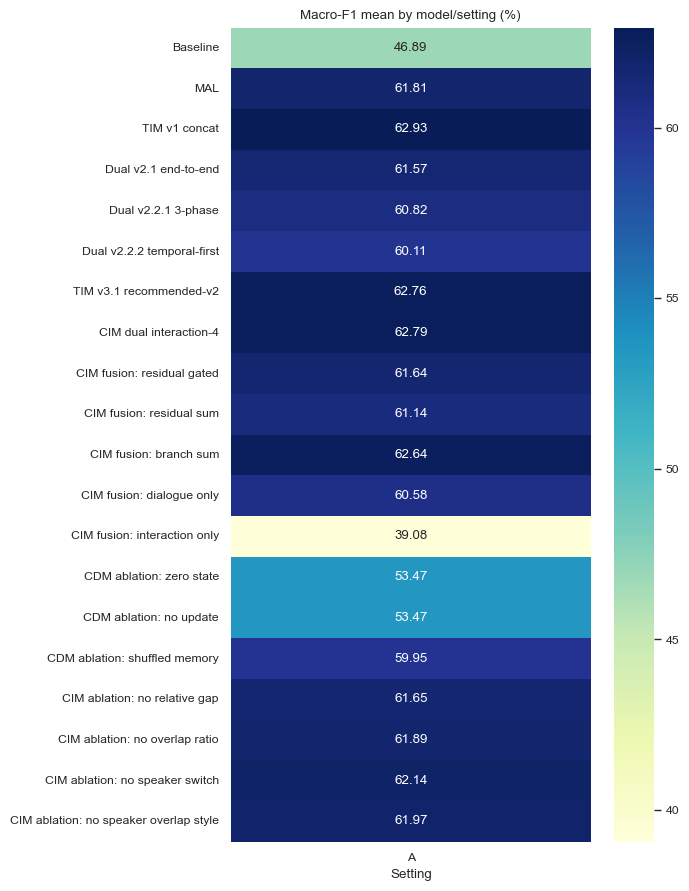

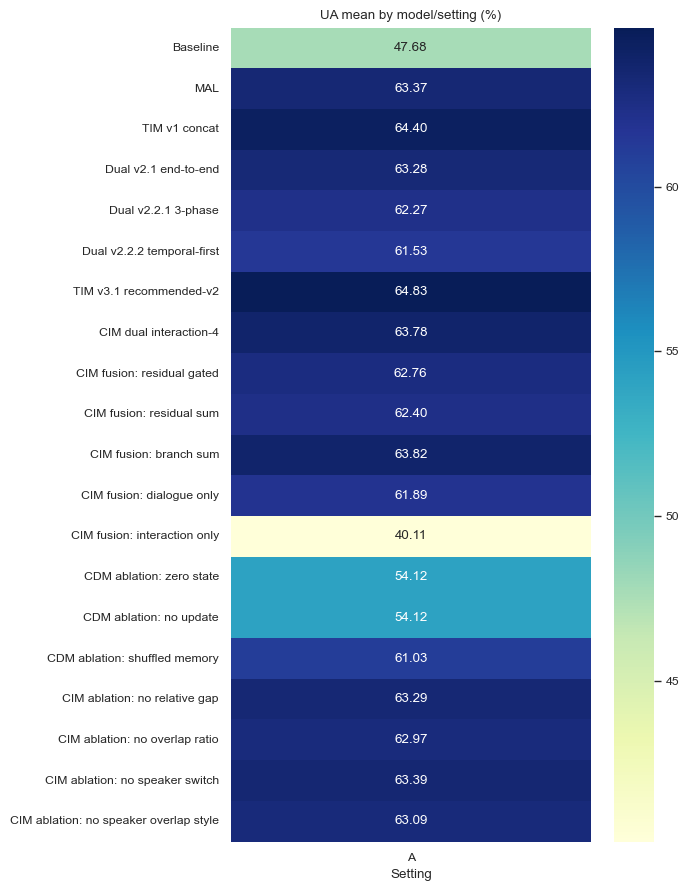

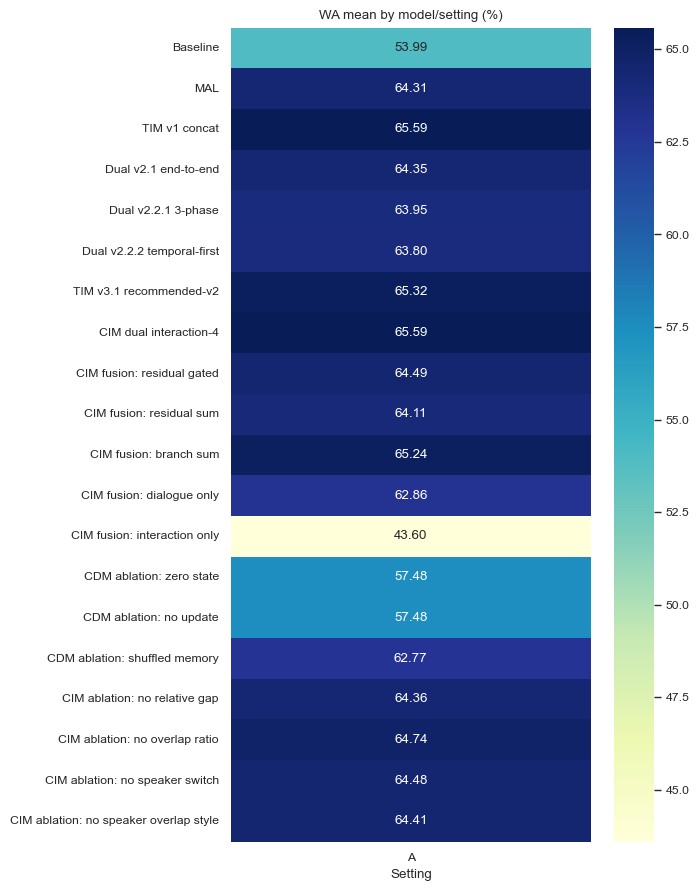

In [5]:
for metric in ["Macro-F1", "UA", "WA"]:
    metric_df = main[main["metric"].eq(metric)].copy()
    if metric_df.empty:
        continue
    heat = metric_df.pivot_table(index="model", columns="setting", values="mean", aggfunc="max") * 100.0
    ordered_models = [m for m in MAIN_MODEL_ORDER if m in heat.index]
    ordered_models.extend(sorted(m for m in heat.index if m not in ordered_models))
    heat = heat.reindex(ordered_models)
    heat.to_csv(OUT_DIR / f"main_model_{metric.lower().replace('-', '_')}_by_setting.csv")
    fig, ax = plt.subplots(figsize=(7, max(3, 0.45 * len(heat))))
    sns.heatmap(heat, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax)
    ax.set_title(f"{metric} mean by model/setting (%)")
    ax.set_xlabel("Setting")
    ax.set_ylabel("")
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"main_model_{metric.lower().replace('-', '_')}_heatmap.png", dpi=180)
    plt.show()


## 5. Held-Out Session Heatmap


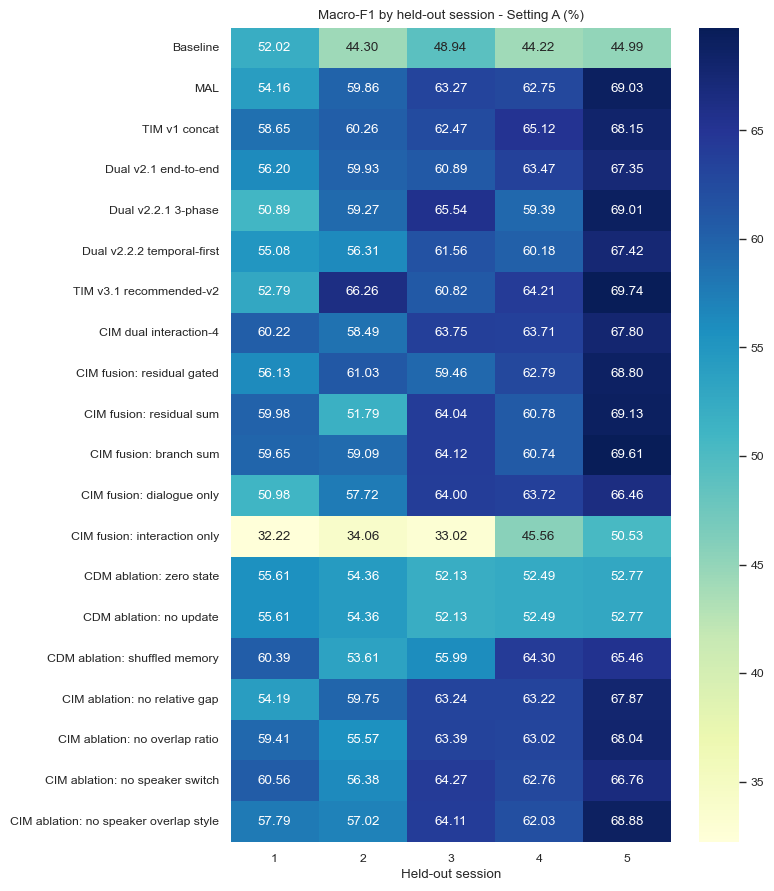

,family,setting,version,model,seed,run_name,test_session,metric,value,summary_path,family_priority
423,versioned_loso,A,control,Baseline,NaN,run_20260630_091825,1,Macro-F1,0.520168,/Users/ngocbao/Documents/Document/research/mai...,0
427,versioned_loso,A,control,Baseline,NaN,run_20260630_091825,2,Macro-F1,0.442987,/Users/ngocbao/Documents/Document/research/mai...,0
431,versioned_loso,A,control,Baseline,NaN,run_20260630_091825,3,Macro-F1,0.489415,/Users/ngocbao/Documents/Document/research/mai...,0
435,versioned_loso,A,control,Baseline,NaN,run_20260630_091825,4,Macro-F1,0.442210,/Users/ngocbao/Documents/Document/research/mai...,0
439,versioned_loso,A,control,Baseline,NaN,run_20260630_091825,5,Macro-F1,0.449884,/Users/ngocbao/Documents/Document/research/mai...,0


In [6]:
main_folds = folds[
    folds["model"].isin(MAIN_MODEL_ORDER)
    & folds["metric"].eq(PRIMARY_METRIC)
    & folds["family"].isin(["versioned_loso", "cim_loso", "cim_full_loso", "cim_ablation_loso", "fusion_model_loso", "mal_ablation_loso", "ablation_model_loso", "ablation_loso", "legacy_loso"])
].copy()
main_folds["family_priority"] = main_folds["family"].map(family_priority).fillna(9)
main_folds = main_folds.sort_values(["model", "test_session", "family_priority", "run_name"], ascending=[True, True, True, False]).drop_duplicates(["setting", "model", "test_session"], keep="first")

for setting, frame in main_folds.groupby("setting"):
    pivot = frame.pivot_table(index="model", columns="test_session", values="value", aggfunc="mean") * 100.0
    ordered_models = [m for m in MAIN_MODEL_ORDER if m in pivot.index]
    ordered_models.extend(sorted(m for m in pivot.index if m not in ordered_models))
    pivot = pivot.reindex(ordered_models)
    pivot.to_csv(OUT_DIR / f"main_model_{PRIMARY_METRIC.lower().replace('-', '_')}_by_session_setting_{setting}.csv")
    fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(pivot))))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax)
    ax.set_title(f"{PRIMARY_METRIC} by held-out session - Setting {setting} (%)")
    ax.set_xlabel("Held-out session")
    ax.set_ylabel("")
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"main_model_{PRIMARY_METRIC.lower().replace('-', '_')}_by_session_setting_{setting}.png", dpi=180)
    plt.show()

display(main_folds.head())


## 6. TIM Ablation Tables


metric,WA,UA,WF1,Macro-F1
model,,,,
TIM-shuffled,63.72 ± 6.69,60.85 ± 3.62,62.99 ± 6.10,60.55 ± 4.74
TIM-zero,65.71 ± 5.52,64.26 ± 4.23,65.40 ± 5.62,62.96 ± 4.74
tim_no_duration,65.74 ± 4.85,63.33 ± 3.35,65.16 ± 4.74,62.43 ± 4.08
tim_no_gap,64.51 ± 6.31,62.61 ± 4.31,63.97 ± 6.59,61.25 ± 5.77
tim_no_overlap,65.27 ± 6.63,64.07 ± 4.50,65.04 ± 6.59,62.50 ± 5.62
tim_no_speaker_switch,64.39 ± 7.06,62.72 ± 4.41,63.79 ± 7.10,61.32 ± 5.91
tim_no_turn_position,63.90 ± 7.80,61.79 ± 5.11,63.31 ± 7.79,60.80 ± 6.76
tim_overlap_only,62.94 ± 8.95,61.74 ± 5.42,62.37 ± 9.91,60.20 ± 8.57


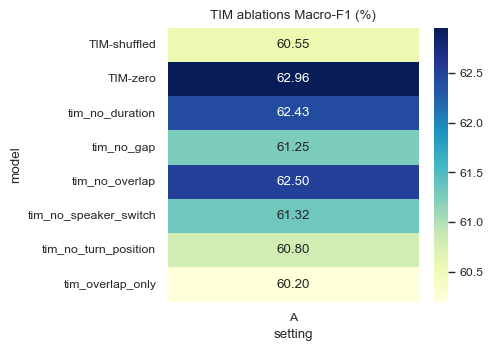

In [7]:
ablation = aggregate[aggregate["family"].eq("tim_ablations")].copy()
if not ablation.empty:
    ablation_table = (
        ablation.assign(mean_std=lambda df: [mean_std_text(m, s) for m, s in zip(df["mean"], df["std"])])
        .pivot_table(index="model", columns="metric", values="mean_std", aggfunc="first")
        .reindex(columns=METRICS)
    )
    ablation_table.to_csv(OUT_DIR / "tim_ablation_summary_table.csv")
    display(ablation_table)

    ablation_heat = ablation[ablation["metric"].eq(PRIMARY_METRIC)].pivot_table(index="model", columns="setting", values="mean", aggfunc="max") * 100.0
    ablation_heat.to_csv(OUT_DIR / f"tim_ablation_{PRIMARY_METRIC.lower().replace('-', '_')}_heatmap.csv")
    fig, ax = plt.subplots(figsize=(5, max(3, 0.45 * len(ablation_heat))))
    sns.heatmap(ablation_heat, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax)
    ax.set_title(f"TIM ablations {PRIMARY_METRIC} (%)")
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"tim_ablation_{PRIMARY_METRIC.lower().replace('-', '_')}_heatmap.png", dpi=180)
    plt.show()
else:
    print("No TIM ablation summaries found.")


## 7. Markdown Report


In [8]:
report = f"""
# Versioned Result Summary

## Main model table

{main_table.to_markdown() if not main_table.empty else 'No main model results found.'}

## TIM ablation table

{ablation_table.to_markdown() if 'ablation_table' in globals() and not ablation_table.empty else 'No TIM ablation results found.'}

## Generated files

- `all_cross_session_aggregate_long.csv`
- `all_cross_session_folds_long.csv`
- `prediction_file_index.csv`
- `prediction_file_index_unique.csv`
- `missing_prediction_files.csv`
- `main_model_summary_table.csv`
- `main_model_macro_f1_by_setting.csv`
- `main_model_macro_f1_by_session_setting_A.csv`
- `tim_ablation_summary_table.csv`
- figures under `figures/`
"""
(OUT_DIR / "versioned_result_summary.md").write_text(report.strip() + "\n", encoding="utf-8")
print(report)





# Versioned Result Summary

## Main model table

|                                                                 | WA           | UA           | WF1          | Macro-F1     |
|:----------------------------------------------------------------|:-------------|:-------------|:-------------|:-------------|
| ('A', 'control', 'Baseline')                                    | 53.99 ± 4.13 | 47.68 ± 3.85 | 50.31 ± 4.04 | 46.89 ± 3.46 |
| ('A', 'control', 'MAL')                                         | 64.31 ± 6.45 | 63.37 ± 3.41 | 63.82 ± 6.84 | 61.81 ± 5.42 |
| ('A', '1', 'TIM v1 concat')                                     | 65.59 ± 5.30 | 64.40 ± 3.05 | 65.24 ± 5.24 | 62.93 ± 3.80 |
| ('A', '2.1', 'Dual v2.1 end-to-end')                            | 64.35 ± 5.15 | 63.28 ± 2.60 | 63.96 ± 5.52 | 61.57 ± 4.15 |
| ('A', '2.2.1', 'Dual v2.2.1 3-phase')                           | 63.95 ± 7.11 | 62.27 ± 5.06 | 63.31 ± 7.66 | 60.82 ± 6.94 |
| ('A', '2.2.2', 'Dual v2.2.2 temporal-first')        

## 8. Saved Outputs


In [9]:
outputs = sorted(p.relative_to(OUT_DIR) for p in OUT_DIR.rglob("*") if p.is_file())
print(f"Saved {len(outputs)} files under {OUT_DIR}")
for path in outputs:
    print(path)


Saved 24 files under /Users/ngocbao/Documents/Document/research/main/speech/exps/demo/reports/versioned_result_summary
all_cross_session_aggregate_long.csv
all_cross_session_folds_long.csv
figures/main_model_macro_f1_by_session_setting_A.png
figures/main_model_macro_f1_heatmap.png
figures/main_model_ua_heatmap.png
figures/main_model_wa_heatmap.png
figures/tim_ablation_macro_f1_heatmap.png
main_model_macro_f1_by_session_setting_A.csv
main_model_macro_f1_by_setting.csv
main_model_summary_table.csv
main_model_ua_by_setting.csv
main_model_wa_by_setting.csv
missing_prediction_files.csv
prediction_file_index.csv
prediction_file_index_unique.csv
session_interaction_intensity_draft.csv
tim_ablation_macro_f1_heatmap.csv
tim_ablation_summary_table.csv
versioned_loso_macro_f1_by_session.csv
versioned_loso_macro_f1_delta_vs_mal.csv
versioned_loso_main_metrics.csv
versioned_loso_per_class_f1.csv
versioned_loso_per_class_f1_delta_vs_mal.csv
versioned_result_summary.md
